In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('13-car_evaluation.csv')

In [4]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [6]:
df.describe()

,vhigh,vhigh.1,2,2.1,small,low,unacc
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [7]:
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

In [8]:
df.columns = col_names

In [9]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [10]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [11]:
# class -> target variable, doors&persons -> numeric variable, persons. rest -> categorical

In [12]:
df["doors"].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [13]:
df["doors"] = df["doors"].replace("5more", "5")

In [14]:
df["doors"].unique()

array(['2', '3', '4', '5'], dtype=object)

In [15]:
df["doors"] = df["doors"].astype(int)

In [16]:
df["persons"].unique()

array(['2', '4', 'more'], dtype=object)

In [17]:
df["persons"] = df["persons"].replace("more", "5")

In [18]:
df["persons"].unique()

array(['2', '4', '5'], dtype=object)

In [19]:
df["persons"] = df["persons"].astype(int)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [21]:
X = df.drop("class", axis=1)
y = df["class"]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=15)

In [24]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer # ColumnTransformer, farklı sütunlara farklı dönüşümler uygulamamızı sağlar:
from sklearn.pipeline import  Pipeline

In [25]:
categorical_cols = ["buying", "maint", "lug_boot", "safety"]
numerical_cols = ["doors", "persons"]

ordinal_encoder = OrdinalEncoder(categories = [ # -> vhigh tarzı yazımları anlayamama durumu olabileceği için categories parametresini biz sırayla yazdık
    ["low","med","high","vhigh"], # buying
    ["low","med","high","vhigh"], #maint
    ["small","med","big"], #lug_boot
    ["low","med","high"] # safety
])

preprocessor = ColumnTransformer(transformers=[
    ('transformation_name_doesnt_matter', ordinal_encoder, categorical_cols),
], remainder="passthrough")

# ColumnTransformer Nedir?
# ColumnTransformer, farklı sütunlara farklı dönüşümler uygulamamızı sağlar:

# Avantajları:
# Tek seferde işlem: Tüm preprocessing'i tek adımda yapar.
# Farklı dönüşümler: Her sütun grubuna farklı işlem uygular.
# Pipeline uyumlu: Scikit-learn pipeline'ları ile uyumlu.
# Hata önleyici: Sütun karışıklığını önler.

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [26]:
pd.DataFrame(X_train)[5].unique()

array([2., 4., 5.])

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0) # "gini" -> default

tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
y_pred = tree_model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print("classification_report: \n ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))

accuracy_score:  0.7861271676300579
classification_report: 
                precision    recall  f1-score   support

         acc       0.54      0.51      0.53       121
        good       0.00      0.00      0.00        21
       unacc       0.85      0.97      0.91       356
       vgood       0.00      0.00      0.00        21

    accuracy                           0.79       519
   macro avg       0.35      0.37      0.36       519
weighted avg       0.71      0.79      0.75       519

confusion_matrix: 
 [[ 62   0  59   0]
 [ 21   0   0   0]
 [ 10   0 346   0]
 [ 21   0   0   0]]


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

[Text(0.3333333333333333, 0.875, 'persons <= 3.0\ngini = 0.451\nsamples = 1208\nvalue = [263, 48, 853, 44]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 409\nvalue = [0, 0, 409, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'safety <= 0.5\ngini = 0.576\nsamples = 799\nvalue = [263, 48, 444, 44]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 269\nvalue = [0, 0, 269, 0]'),
 Text(0.6666666666666666, 0.375, 'buying <= 1.5\ngini = 0.63\nsamples = 530\nvalue = [263, 48, 175, 44]'),
 Text(0.5, 0.125, 'gini = 0.647\nsamples = 270\nvalue = [142, 48, 36, 44]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.498\nsamples = 260\nvalue = [121, 0, 139, 0]')]

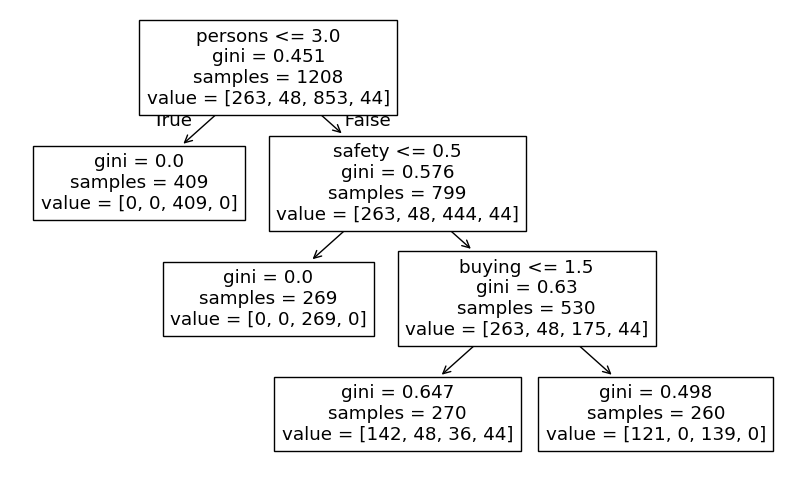

In [32]:
plt.figure(figsize=(10,6))
from sklearn import tree

columns_names = categorical_cols + numerical_cols

tree.plot_tree(tree_model.fit(X_train,y_train), feature_names=columns_names)

In [33]:
# hyperparameter tuning

In [34]:
param = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter" : ["best", "random"],
    "max_depth": [1,2,3,4,5,15,None],
    "max_features": ["sqrt", "log2", None]
}

In [35]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=DecisionTreeClassifier(random_state=15), param_grid=param, cv=5, scoring="accuracy")

In [36]:
import warnings
warnings.filterwarnings("ignore")

grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=15)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [37]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'best'}

In [38]:
y_pred = grid.predict(X_test)

In [39]:
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print("classification_report: \n ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))

accuracy_score:  0.9730250481695568
classification_report: 
                precision    recall  f1-score   support

         acc       0.91      0.98      0.94       121
        good       1.00      0.86      0.92        21
       unacc       1.00      0.97      0.99       356
       vgood       0.95      1.00      0.98        21

    accuracy                           0.97       519
   macro avg       0.97      0.95      0.96       519
weighted avg       0.97      0.97      0.97       519

confusion_matrix: 
 [[119   0   1   1]
 [  3  18   0   0]
 [  9   0 347   0]
 [  0   0   0  21]]


In [40]:
# hyperparameter tuning sonucu accuracy ve bütün dağılımlar düzeldi.

In [41]:
tree_model_new = DecisionTreeClassifier(criterion="entropy", splitter="best", max_depth=None, max_features=None)

In [42]:
tree_model_new.fit(X_train,y_train)
y_pred = tree_model_new.predict(X_test)

print("accuracy_score: ", accuracy_score(y_test,y_pred))
print("classification_report: \n ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))

accuracy_score:  0.9730250481695568
classification_report: 
                precision    recall  f1-score   support

         acc       0.91      0.98      0.94       121
        good       1.00      0.86      0.92        21
       unacc       1.00      0.97      0.99       356
       vgood       0.95      1.00      0.98        21

    accuracy                           0.97       519
   macro avg       0.97      0.95      0.96       519
weighted avg       0.97      0.97      0.97       519

confusion_matrix: 
 [[119   0   1   1]
 [  3  18   0   0]
 [  9   0 347   0]
 [  0   0   0  21]]


[Text(0.6140202702702703, 0.9615384615384616, 'persons <= 3.0\nentropy = 1.192\nsamples = 1208\nvalue = [263, 48, 853, 44]'),
 Text(0.6005067567567568, 0.8846153846153846, 'entropy = 0.0\nsamples = 409\nvalue = [0, 0, 409, 0]'),
 Text(0.6072635135135136, 0.9230769230769231, 'True  '),
 Text(0.6275337837837838, 0.8846153846153846, 'safety <= 0.5\nentropy = 1.473\nsamples = 799\nvalue = [263, 48, 444, 44]'),
 Text(0.620777027027027, 0.9230769230769231, '  False'),
 Text(0.6140202702702703, 0.8076923076923077, 'entropy = 0.0\nsamples = 269\nvalue = [0, 0, 269, 0]'),
 Text(0.6410472972972973, 0.8076923076923077, 'buying <= 1.5\nentropy = 1.641\nsamples = 530\nvalue = [263, 48, 175, 44]'),
 Text(0.40371621621621623, 0.7307692307692307, 'maint <= 1.5\nentropy = 1.745\nsamples = 270\nvalue = [142, 48, 36, 44]'),
 Text(0.19932432432432431, 0.6538461538461539, 'safety <= 1.5\nentropy = 1.805\nsamples = 134\nvalue = [43, 48, 8, 35]'),
 Text(0.08108108108108109, 0.5769230769230769, 'lug_boot <= 0

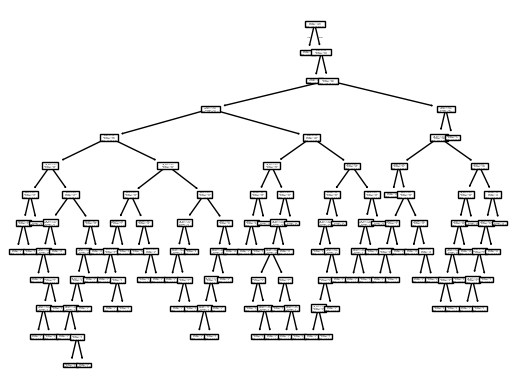

In [43]:
tree.plot_tree(tree_model_new.fit(X_train,y_train), feature_names=columns_names)

In [44]:
# gördüğünüz gibi max_depth olmadan ağaç sürekli büyümeye devam eder, bu veri setinde doğruluğu artırıyor gibi görünse de
# başka bir örnekte kesinlikle aşırı öğrenme (overfitting) şansını artırabilir. bu yüzden budamaya (pruning) ihtiyacımız var.
# ön budama (prepruning) veya son budama (postpruning) yapabiliriz, max_depth parametresiyle oynayarak. bu yüzden size göstermek için başlangıçta max_depth 3 seçtim

# Pruning - Budama

In [45]:
df_new = pd.read_csv("11-iris.csv")

In [46]:
df_new.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [47]:
X=df_new.drop(["Id", "Species"], axis=1)
y=df_new["Species"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [49]:
tree_model = DecisionTreeClassifier()

In [50]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.3076923076923077, 0.9285714285714286, 'PetalLengthCm <= 2.45\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'PetalLengthCm <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'PetalWidthCm <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'PetalWidthCm <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.38461538461538464, 0.5, 'SepalWidthCm <= 2.65\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.3076923076923077, 0.35714285714285

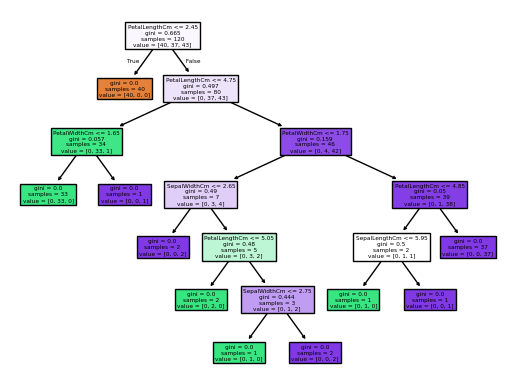

In [51]:
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names=X_train.columns, filled=True) # filled = true -> Ağacı renklendirir.

In [52]:
y_pred = tree_model.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print("classification_report: \n ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))

accuracy_score:  0.9666666666666667
classification_report: 
                   precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.88      1.00      0.93         7

       accuracy                           0.97        30
      macro avg       0.96      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30

confusion_matrix: 
 [[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]


In [53]:
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train,y_train)
y_pred = tree_model.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print("classification_report: \n ", classification_report(y_test,y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))

accuracy_score:  0.9333333333333333
classification_report: 
                   precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.78      1.00      0.88         7

       accuracy                           0.93        30
      macro avg       0.93      0.95      0.93        30
   weighted avg       0.95      0.93      0.93        30

confusion_matrix: 
 [[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]


[Text(0.375, 0.875, 'PetalLengthCm <= 2.45\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'PetalLengthCm <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'PetalWidthCm <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.375, 'PetalWidthCm <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.625, 0.125, 'gini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.875, 0.125, 'gini = 0.05\nsamples = 39\nvalue = [0, 1, 38]')]

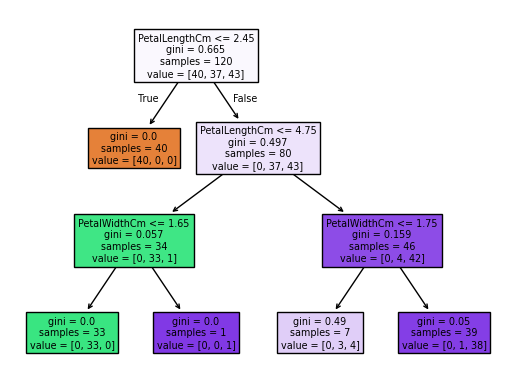

In [54]:
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names=X_train.columns, filled=True)